Task was destroyed but it is pending!
task: <Task pending name='Task-75' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-76' coro=<_async_in_context.<locals>.preserve_context() running at /opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/tokenize.py:527: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-76' coro=<_async_in_context.<locals>.preserve_context() ru

ACTIVITY RECOGNITION — 1D CNN (32→64→64) + 11 Activities
NO BatchNorm (quantization-friendly), with augmentation + L2
TensorFlow version: 2.13.0
GPU available: True

STEP 1: Loading Preprocessed Data
Training: (9871, 600, 8)
Test: (906, 600, 8)

Activities (11):
  0: knuckles_cracking
  1: hand_tapping
  2: sitting
  3: standing
  4: smoking
  5: nail_biting
  6: hair_pulling
  7: nape_rubbing
  8: hand_scratching
  9: forehead_rubbing
  10: ear_rubbing

STEP 1.5: Data Augmentation
Creating 2 augmented copies of training data...
Original training: 9,871 windows
Augmented training: 29,613 windows (3x)

STEP 2: Building 1D CNN (32→64→64) — NO BatchNorm
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 600, 32)           1312      
                                                                 
 pool1 (MaxPooling1D)        (None, 300, 32)           

2026-06-22 14:53:32.750266: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


741/741 [==============================] - ETA: 0s - loss: 1.2902 - accuracy: 0.5300

2026-06-22 14:53:49.098243: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


741/741 [==============================] - 20s 26ms/step - loss: 1.2902 - accuracy: 0.5300 - val_loss: 0.7216 - val_accuracy: 0.7283 - lr: 0.0010
Epoch 2/180
741/741 [==============================] - 19s 25ms/step - loss: 0.6758 - accuracy: 0.7534 - val_loss: 0.4425 - val_accuracy: 0.8548 - lr: 0.0010
Epoch 3/180
741/741 [==============================] - 19s 25ms/step - loss: 0.4830 - accuracy: 0.8311 - val_loss: 0.3440 - val_accuracy: 0.8879 - lr: 0.0010
Epoch 4/180
741/741 [==============================] - 19s 25ms/step - loss: 0.3895 - accuracy: 0.8667 - val_loss: 0.2608 - val_accuracy: 0.9230 - lr: 0.0010
Epoch 5/180
741/741 [==============================] - 19s 25ms/step - loss: 0.3313 - accuracy: 0.8902 - val_loss: 0.2565 - val_accuracy: 0.9117 - lr: 0.0010
Epoch 6/180
741/741 [==============================] - 19s 25ms/step - loss: 0.2870 - accuracy: 0.9106 - val_loss: 0.2052 - val_accuracy: 0.9377 - lr: 0.0010
Epoch 7/180
741/741 [==============================] - 19s 26ms/

2026-06-22 15:27:51.011346: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Classification Report:
                   precision    recall  f1-score   support

knuckles_cracking      1.000     0.989     0.994        87
     hand_tapping      1.000     1.000     1.000        62
          sitting      1.000     1.000     1.000        63
         standing      1.000     1.000     1.000        64
          smoking      0.548     0.367     0.440       109
      nail_biting      0.347     0.515     0.415        66
     hair_pulling      0.897     1.000     0.946        96
     nape_rubbing      0.969     0.341     0.504        91
  hand_scratching      0.487     1.000     0.655        91
 forehead_rubbing      0.229     0.126     0.163        87
      ear_rubbing      0.953     0.911     0.932        90

         accuracy                          0.728       906
        macro avg      0.766     0.750     0.732       906
     weighted avg      0.754     0.728     0.712       906


STEP 5: Visualizing Results


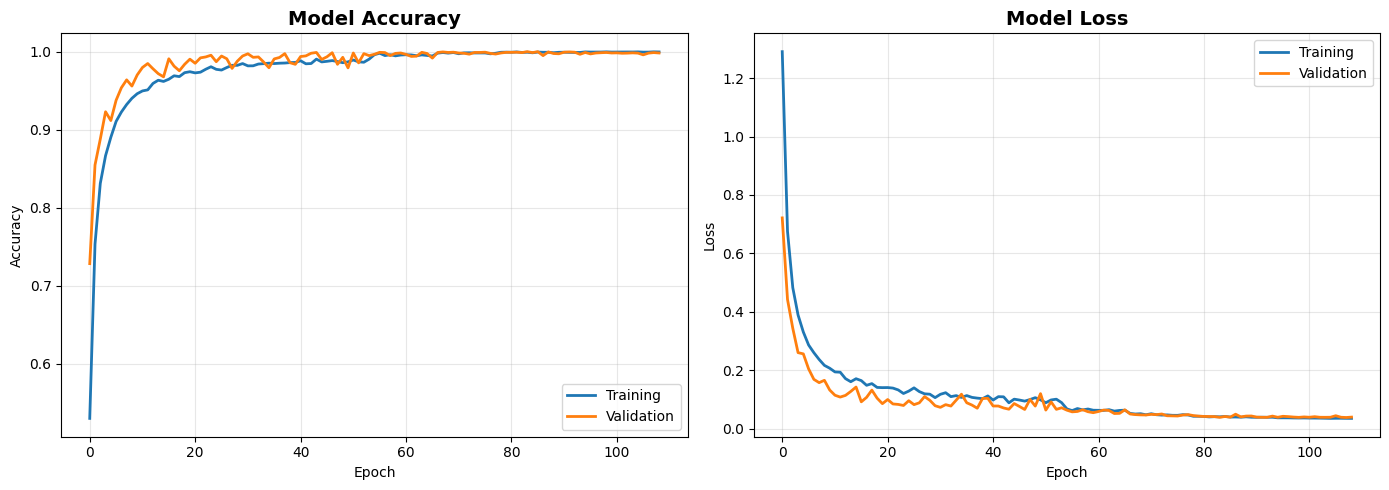

Saved: ../results/training_history.png


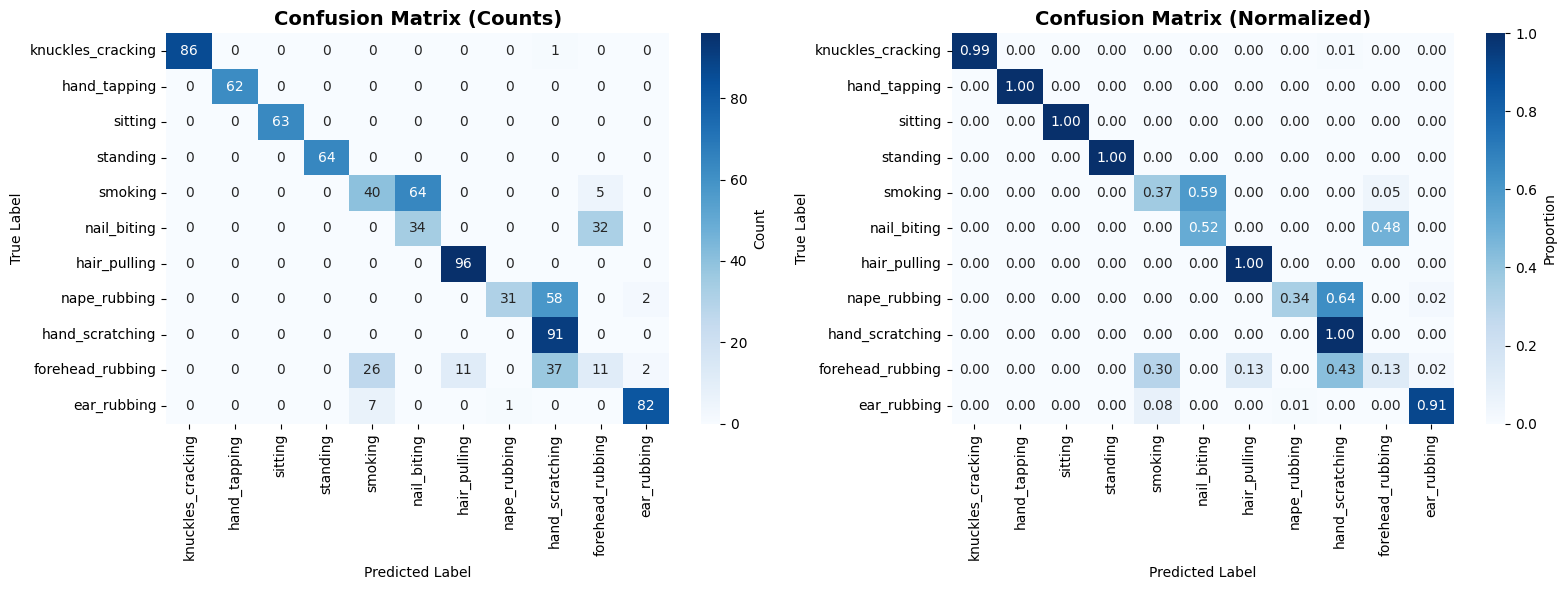

Saved: ../results/confusion_matrix.png

STEP 6: Saving Model
Saved: ../models/activity_model.h5
Saved: ../models/training_info.pkl

TRAINING COMPLETE!
  Test Accuracy: 72.85%
  Test Loss: 1.7180
  Parameters: 28,843
  Activities: 11
  Architecture: 1D CNN (32→64→64, GlobalAvgPool, NO BN, L2)
  Window: 600 samples (12.0s), leave-one-out (test user 3)
  Features: 8 (6 raw + 2 magnitude)
  Epochs trained: 109/180
  Data augmentation: 3x (noise + scale + time shift)


/opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("ACTIVITY RECOGNITION — 1D CNN (32→64→64) + 11 Activities")
print("NO BatchNorm (quantization-friendly), with augmentation + L2")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# STEP 1: Load Preprocessed Data
print("\n" + "="*60)
print("STEP 1: Loading Preprocessed Data")
print("="*60)

data_dir = Path('../data/processed')

X_train = np.load(data_dir / 'X_train.npy')
y_train = np.load(data_dir / 'y_train.npy')
X_test = np.load(data_dir / 'X_test.npy')
y_test = np.load(data_dir / 'y_test.npy')

with open(data_dir / 'preprocessing_info.pkl', 'rb') as f:
    preprocessing_info = pickle.load(f)

label_to_activity = preprocessing_info['label_to_activity']
config = preprocessing_info['config']

print(f"Training: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"\nActivities ({len(label_to_activity)}):")
for label, activity in label_to_activity.items():
    print(f"  {label}: {activity}")

# STEP 1.5: Data Augmentation
print("\n" + "="*60)
print("STEP 1.5: Data Augmentation")
print("="*60)

def augment_batch(X, y, noise_std=0.1, scale_range=(0.9, 1.1), time_shift_max=20):
    """Apply random augmentations to help cross-user generalization."""
    X_aug = X.copy()
    batch_size = X_aug.shape[0]

    # 1. Gaussian noise
    noise = np.random.normal(0, noise_std, X_aug.shape)
    X_aug = X_aug + noise

    # 2. Random scaling per-sample
    scales = np.random.uniform(scale_range[0], scale_range[1], (batch_size, 1, 1))
    X_aug = X_aug * scales

    # 3. Random time shift
    X_shifted = np.zeros_like(X_aug)
    for i in range(batch_size):
        shift = np.random.randint(-time_shift_max, time_shift_max + 1)
        if shift > 0:
            X_shifted[i, shift:, :] = X_aug[i, :-shift, :]
            X_shifted[i, :shift, :] = X_aug[i, :shift, :]
        elif shift < 0:
            X_shifted[i, :shift, :] = X_aug[i, -shift:, :]
            X_shifted[i, shift:, :] = X_aug[i, shift:, :]
        else:
            X_shifted[i] = X_aug[i]

    return X_shifted, y

num_augmented_copies = 2
print(f"Creating {num_augmented_copies} augmented copies of training data...")

X_all = [X_train]
y_all = [y_train]
for i in range(num_augmented_copies):
    X_aug, y_aug = augment_batch(X_train, y_train)
    X_all.append(X_aug)
    y_all.append(y_aug)

X_train_aug = np.concatenate(X_all, axis=0).astype(np.float32)
y_train_aug = np.concatenate(y_all, axis=0)

shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]

print(f"Original training: {X_train.shape[0]:,} windows")
print(f"Augmented training: {X_train_aug.shape[0]:,} windows ({num_augmented_copies+1}x)")

# STEP 2: Build 1D CNN Model — NO BatchNorm (quantization-friendly)
print("\n" + "="*60)
print("STEP 2: Building 1D CNN (32→64→64) — NO BatchNorm")
print("="*60)

L2_REG = 1e-4

def build_model(input_shape, num_classes):
    """3-block 1D CNN WITHOUT BatchNorm — proven to quantize cleanly.
    BN causes INT8 quantization issues (19% drop with BN vs <1% without).
    L2 + dropout provide sufficient regularization with augmented data."""
    model = models.Sequential([
        layers.Input(shape=input_shape, name='input'),

        # Block 1: 32 filters
        layers.Conv1D(32, kernel_size=5, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG), name='conv1'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),
        layers.Dropout(0.2, name='drop1'),

        # Block 2: 64 filters
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG), name='conv2'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),
        layers.Dropout(0.2, name='drop2'),

        # Block 3: 64 filters
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG), name='conv3'),
        layers.MaxPooling1D(pool_size=2, name='pool3'),

        # GlobalAvgPool + classifier
        layers.GlobalAveragePooling1D(name='gap'),
        layers.Dropout(0.5, name='drop4'),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG), name='fc1'),
        layers.Dropout(0.5, name='drop5'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])

    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (600, 8)
num_classes = len(label_to_activity)

model = build_model(input_shape, num_classes)

model.compile(
    optimizer=keras.optimizers.legacy.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"No BatchNorm — should quantize cleanly like v1 architecture")

# STEP 3: Train Model
print("\n" + "="*60)
print("STEP 3: Training Model")
print("="*60)

EPOCHS = 180
BATCH_SIZE = 32

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max', patience=25,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', mode='max', factor=0.5, patience=10,
        min_lr=1e-6, verbose=1
    ),
]

print(f"Training for up to {EPOCHS} epochs...")
print(f"  Early stopping: val_accuracy, patience=25")
print(f"  LR schedule: ReduceLROnPlateau on val_accuracy (factor=0.5, patience=10)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  L2 regularization: {L2_REG}")
print(f"  Data augmentation: 3x (noise + scale + time shift)")
print(f"  NO BatchNorm (quantization-friendly)")

history = model.fit(
    X_train_aug, y_train_aug,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")
print(f"Stopped at epoch {len(history.history['accuracy'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

# STEP 4: Evaluate Model
print("\n" + "="*60)
print("STEP 4: Evaluating Model")
print("="*60)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[label_to_activity[i] for i in range(num_classes)],
    digits=3
))

# STEP 5: Visualize Results
print("\n" + "="*60)
print("STEP 5: Visualizing Results")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/training_history.png")

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, weight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, weight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(results_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/confusion_matrix.png")

# STEP 6: Save Model
print("\n" + "="*60)
print("STEP 6: Saving Model")
print("="*60)

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model.save(models_dir / 'activity_model.h5')
print(f"Saved: {models_dir / 'activity_model.h5'}")

training_info = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'total_params': int(total_params),
    'epochs_trained': len(history.history['accuracy']),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'config': config,
    'label_to_activity': label_to_activity,
    'input_shape': input_shape,
    'num_classes': num_classes
}

with open(models_dir / 'training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f"Saved: {models_dir / 'training_info.pkl'}")

# SUMMARY
print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Parameters: {total_params:,}")
print(f"  Activities: {num_classes}")
print(f"  Architecture: 1D CNN (32→64→64, GlobalAvgPool, NO BN, L2)")
print(f"  Window: {input_shape[0]} samples ({input_shape[0]/50:.1f}s), leave-one-out (test user 3)")
print(f"  Features: {input_shape[1]} (6 raw + 2 magnitude)")
print(f"  Epochs trained: {len(history.history['accuracy'])}/{EPOCHS}")
print(f"  Data augmentation: 3x (noise + scale + time shift)")